### Tutorial Followed: [Multi-Label Text Classification Model with DistilBERT and Hugging Face Transformers in PyTorch](https://www.youtube.com/watch?v=ZYc9za75Chk)

#### Processing Data:

In [131]:
!pip install -U accelerate
!pip install -U transformers

In [132]:
import pandas as pd
df = pd.read_csv('poems_for_analysis .csv', usecols=['Text', 'Theme'])
print(df)

                                                  Text             Theme
0    Bolinao, Philippines\n\nI am worried about ten...      Nature, Love
1    Batter my heart, three-personed God, for you\n...        Loss, Hope
2    I’ve known rivers:\n\nI’ve known rivers ancien...      Nature, Love
3    To fling my arms wide\n\nIn some place of the ...  Hope, Resilience
4    The cry of the cicada\n\nGives us no sign\n\nT...      Nature, Loss
..                                                 ...               ...
99   (To F. S.)\n\nI loved my friend.\n\nThere’s no...      Love, Beauty
100  The past and present wilt—I have fill’d them, ...      Hope, Beauty
101  And a youth said, Speak to us of Friendship.\n...        Hope, Love
102  Lovers, forget your love,\nAnd list to the lov...        Love, Loss
103  My sorrow, when she’s here with me,\n\nThinks ...    Nature, Beauty

[104 rows x 2 columns]


<Axes: ylabel='Frequency'>

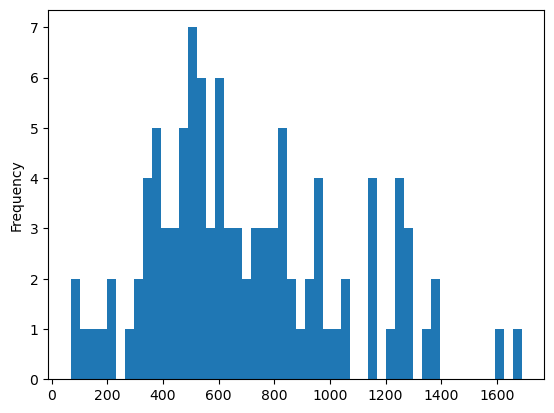

In [133]:
df['Text'].str.len().plot.hist(bins=50)

In [134]:
df['length'] = df['Text'].str.len()
print(df['length'].describe())


count     104.000000
mean      702.365385
std       347.365761
min        68.000000
25%       471.500000
50%       620.000000
75%       921.500000
max      1689.000000
Name: length, dtype: float64


In [135]:
# chatgpt helped me understand how to get rid duplicate themes
import ast
df['Theme'] = df['Theme'].fillna('').apply(lambda x: [t.strip() for t in x.split(',') if t.strip() != ''])

In [136]:
# list comprehensive method
theme_counts = [g for gen in df['Theme'] for g in gen]
theme_counts_series = pd.Series(theme_counts).value_counts()
print(theme_counts_series)

Nature        39
Loss          37
Beauty        33
Love          30
Hope          26
Resilience    25
Happiness     18
Name: count, dtype: int64


- this is a small, manually tagged dataset- meaning there will be biases and inaccuracies, I am unsure how to comprehend my larger dataset without doing this step however since they aren't already tagged by themes 

#### Label Encoding:

In [138]:
from sklearn.preprocessing import MultiLabelBinarizer

In [139]:
multilabel = MultiLabelBinarizer()

label = multilabel.fit_transform(df['Theme'])

texts = df['Text'].tolist()

In [140]:
# chatgpt helped create a clear 'checklist' to see if it has all the themes and no duplicates like previously
print(multilabel.classes_)  
print(label.shape)                
print(label[0])                    

['Beauty' 'Happiness' 'Hope' 'Loss' 'Love' 'Nature' 'Resilience']
(104, 7)
[0 0 0 0 1 1 0]


In [141]:
print(label)

[[0 0 0 0 1 1 0]
 [0 0 1 1 0 0 0]
 [0 0 0 0 1 1 0]
 [0 0 1 0 0 0 1]
 [0 0 0 1 0 1 0]
 [1 0 0 0 0 1 0]
 [0 1 0 0 0 1 0]
 [0 0 0 0 1 1 0]
 [0 0 0 0 0 1 1]
 [1 0 0 0 1 0 0]
 [0 1 0 0 0 1 0]
 [0 1 0 0 1 0 0]
 [1 0 0 0 1 0 0]
 [0 0 0 0 0 1 1]
 [0 0 1 0 0 0 1]
 [0 0 0 1 0 1 0]
 [1 0 0 0 0 0 1]
 [0 1 1 0 0 0 0]
 [0 0 1 0 0 0 1]
 [0 0 0 1 1 0 0]
 [1 0 0 0 0 1 0]
 [1 0 0 0 1 0 0]
 [1 0 0 1 0 0 0]
 [0 1 0 0 1 0 0]
 [0 0 0 0 1 1 0]
 [0 0 0 0 1 0 1]
 [0 0 1 0 0 0 1]
 [0 0 0 1 0 1 0]
 [1 0 0 0 1 0 0]
 [1 0 0 0 0 1 0]
 [0 0 0 1 0 0 1]
 [0 1 0 0 0 1 0]
 [0 1 0 0 0 1 0]
 [1 0 0 1 0 0 0]
 [0 0 0 1 0 0 1]
 [0 0 0 1 0 0 1]
 [1 1 0 0 0 0 0]
 [0 0 1 1 0 0 0]
 [1 0 0 0 1 0 0]
 [0 0 1 0 0 1 0]
 [1 0 0 0 0 1 0]
 [1 0 0 0 0 1 0]
 [0 1 0 0 1 0 0]
 [0 0 1 0 0 0 1]
 [1 0 0 0 0 1 0]
 [0 1 0 1 0 0 0]
 [0 0 0 0 1 1 0]
 [0 1 0 0 0 0 1]
 [0 0 1 0 0 0 1]
 [0 1 0 0 1 0 0]
 [0 0 0 1 1 0 0]
 [1 0 0 0 0 1 0]
 [1 0 0 0 0 1 0]
 [0 0 0 1 0 1 0]
 [1 1 0 0 0 0 0]
 [0 0 0 1 0 0 1]
 [0 0 0 1 0 1 0]
 [1 0 0 0 1 0 0]
 [0 0 0 1 0 0 

#### Building Model:

In [142]:
import torch
from transformers import DistilBertTokenizer, AutoTokenizer
from transformers import DistilBertForSequenceClassification, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset

In [143]:
train_texts, val_texts, train_labels, val_labels = train_test_split(texts, label, test_size=0.15, random_state=42)

In [144]:
checkpoint = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(checkpoint)
model = DistilBertForSequenceClassification.from_pretrained(checkpoint, num_labels=len(label[0]),
                                                            problem_type="multi_label_classification")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#### Building Custom Dataset:

In [145]:
class CustomDataset(Dataset):
    def __init__(self, texts, label, tokenizer, max_len=128):
        self.texts = texts
        self.label = label
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        labels = torch.tensor(self.label[idx], dtype=torch.float)

        encoding = self.tokenizer(text, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': labels
        }

In [146]:
train_dataset = CustomDataset(train_texts, train_labels, tokenizer)
val_dataset = CustomDataset(val_texts, val_labels, tokenizer)

#### Multi-Label Classification Evaluation Metrics:

In [147]:
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, hamming_loss
from transformers import EvalPrediction
import torch

def multi_labels_metrics(predictions, labels, threshold=0.3):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))

    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs>=threshold)] = 1
    y_true = labels

    f1 = f1_score(y_true, y_pred, average = 'macro')
    roc_auc = roc_auc_score(y_true, y_pred, average='macro')
    hamming = hamming_loss(y_true, y_pred)

    metrics = {
        "roc_auc": roc_auc,
        "hamming_loss": hamming,
        "f1": f1
    }

    return metrics

def compute_metrics(p:EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions

    result = multi_labels_metrics(predictions=preds,
                                 labels=p.label_ids)
    
    return result

#### Training Arguments:

In [148]:
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    output_dir = './results',
    num_train_epochs=3,
    save_steps=1000,
    save_total_limit=2
)

trainer = Trainer(model=model,
                  args=args,
                  eval_dataset=val_dataset,
                  compute_metrics=compute_metrics)

In [149]:
trainer.evaluate()

/opt/anaconda3/envs/envname/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.6887847781181335,
 'eval_model_preparation_time': 0.0007,
 'eval_roc_auc': 0.5,
 'eval_hamming_loss': 0.7142857142857143,
 'eval_f1': 0.4249252530913204,
 'eval_runtime': 0.42,
 'eval_samples_per_second': 38.092,
 'eval_steps_per_second': 4.761}

**What these Results Mean:**
---
- `eval_loss: 0.688...` = guessing/not learning much
- `eval_roc_auc: 0.5` = random/not discriminating well
- `eval_hamming_loss: 0.714...` = 71% of the labels are incorrect
- `eval_f1: 0.424...` = poor balance
